# Census Income

## By: Ayush Trivedi

### Importing Libraries

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

### Loading the Dataset

In [2]:
adult_df = pd.read_csv(r"C:\Users\ayush\Downloads\Python Projects\Census-Income\Data-sets\adult.csv")
census_df = pd.read_csv(r"C:\Users\ayush\Downloads\Python Projects\Census-Income\Data-sets\census-income (7).csv")

### Exploratory Data Analysis

In [3]:
adult_df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [5]:
census_df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [8]:
adult_df.info()
adult_df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


(48842, 15)

In [9]:
census_df.info()
census_df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              32561 non-null  int64 
 1    workclass       32561 non-null  object
 2    fnlwgt          32561 non-null  int64 
 3    education       32561 non-null  object
 4    education-num   32561 non-null  int64 
 5    marital-status  32561 non-null  object
 6    occupation      32561 non-null  object
 7    relationship    32561 non-null  object
 8    race            32561 non-null  object
 9    sex             32561 non-null  object
 10   capital-gain    32561 non-null  int64 
 11   capital-loss    32561 non-null  int64 
 12   hours-per-week  32561 non-null  int64 
 13   native-country  32561 non-null  object
 14                   32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


(32561, 15)

In [10]:
census_df.columns = census_df.columns.str.strip()

In [11]:
for col in adult_df.select_dtypes(include=['object']).columns:
    adult_df[col] = adult_df[col].replace('?', np.nan)

for col in census_df.select_dtypes(include=['object']).columns:
    census_df[col] = census_df[col].replace('?', np.nan)

In [12]:
adult_df.dropna(inplace=True)
census_df.dropna(inplace=True)

### Data  Visualization

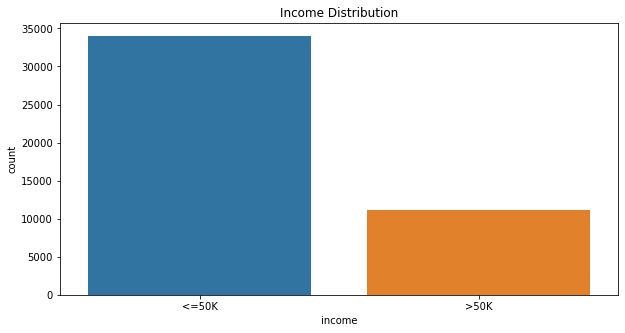

In [13]:
plt.figure(figsize=(10, 5))
sns.countplot(x='income', data=adult_df)
plt.title("Income Distribution")
plt.show()

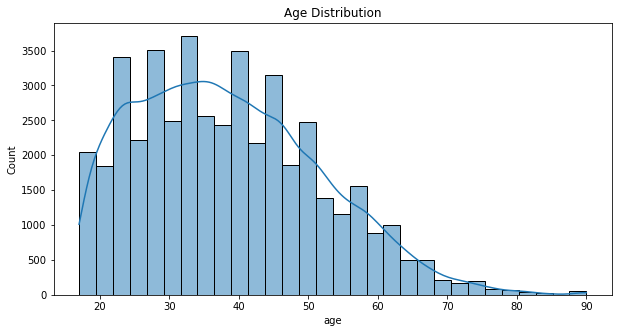

In [14]:
plt.figure(figsize=(10, 5))
sns.histplot(adult_df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

### Label Encoding

In [15]:
le = LabelEncoder()
for col in adult_df.select_dtypes(include=['object']).columns:
    adult_df[col] = le.fit_transform(adult_df[col])

### Using Various Machine Learning Algorithms

In [16]:
X = adult_df.drop(columns=['income'])
y = adult_df['income']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Support Vector Machine": SVC()
}

In [23]:
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"Accuracy for {name}: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))
    print("-" * 50)

Training Random Forest...
Accuracy for Random Forest: 0.8557
              precision    recall  f1-score   support

           0       0.88      0.93      0.91      6842
           1       0.74      0.62      0.68      2203

    accuracy                           0.86      9045
   macro avg       0.81      0.78      0.79      9045
weighted avg       0.85      0.86      0.85      9045

--------------------------------------------------
Training Gradient Boosting...
Accuracy for Gradient Boosting: 0.8671
              precision    recall  f1-score   support

           0       0.88      0.95      0.92      6842
           1       0.80      0.60      0.69      2203

    accuracy                           0.87      9045
   macro avg       0.84      0.78      0.80      9045
weighted avg       0.86      0.87      0.86      9045

--------------------------------------------------
Training Logistic Regression...
Accuracy for Logistic Regression: 0.8211
              precision    recall  f1-sco